In [2]:
import torch

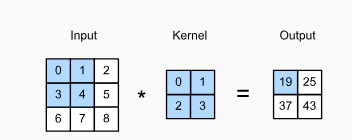

In [3]:
# phép tích chập - thực ra là phép tương quan chéo
def corr2d(X, K):
    h, w = K.shape
    Y = torch.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i, j] = (X[i:i+h, j:j+w] * K).sum()
    return Y
X = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
K = torch.tensor([[0.0, 1.0], [2.0, 3.0]])
Y = corr2d(X, K)
print(Y)

tensor([[19., 25.],
        [37., 43.]])


In [4]:
# lớp tích chập thực  hiện tương quan chéo giữa đầu vào và kernel,
#  sau đó cộng thêm một hệ số bias
from torch import nn
class Conv2D(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.weight = nn.Parameter(torch.rand(kernel_size))
        self.bias = nn.Parameter(torch.zeros(1))
    def forward(self, x):
        return corr2d(x, self.weight) + self.bias
    
conv2d = Conv2D(kernel_size=(2, 2))
print(conv2d.weight)


Parameter containing:
tensor([[0.3111, 0.3412],
        [0.9603, 0.4005]], requires_grad=True)


In [5]:
# phát hiện cạnh
X = torch.ones((6, 8))
X[:, 2:6] = 0
X # ảnh 6x8 có một dải đen ở giữa

tensor([[1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.]])

In [6]:
#kernel k phát hiện cạnh theo đạo hàm bậc 1 theo chiều ngang(sobel)
K = torch.tensor([[1.0, -1.0]])

In [7]:
Y = corr2d(X, K)
Y

tensor([[ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.]])

In [8]:
# mô phỏng quá trình học của một lớp tích chập bằng cách sử dụng thuật toán lan truyền ngược để cập nhật trọng số của kernel
# Construct a two-dimensional convolutional layer with 1 output channel and a
# kernel of shape (1, 2). For the sake of simplicity, we ignore the bias here
conv2d = nn.LazyConv2d(1, kernel_size=(1, 2), bias=False)

# The two-dimensional convolutional layer uses four-dimensional input and
# output in the format of (example, channel, height, width), where the batch
# size (number of examples in the batch) and the number of channels are both 1
X = X.reshape((1, 1, 6, 8))
Y = Y.reshape((1, 1, 6, 7))
lr = 3e-2  # Learning rate

for i in range(10):
    Y_hat = conv2d(X)
    l = (Y_hat - Y) ** 2
    conv2d.zero_grad()
    l.sum().backward()
    # Update the kernel
    conv2d.weight.data[:] -= lr * conv2d.weight.grad
    if (i + 1) % 2 == 0:
        print(f'epoch {i + 1}, loss {l.sum():.3f}')

epoch 2, loss 2.141
epoch 4, loss 0.359
epoch 6, loss 0.060
epoch 8, loss 0.010
epoch 10, loss 0.002


In [9]:
conv2d.weight.data.reshape((1, 2))

tensor([[ 0.9922, -0.9926]])

# Tích chập với nhiều kênh đầu vào
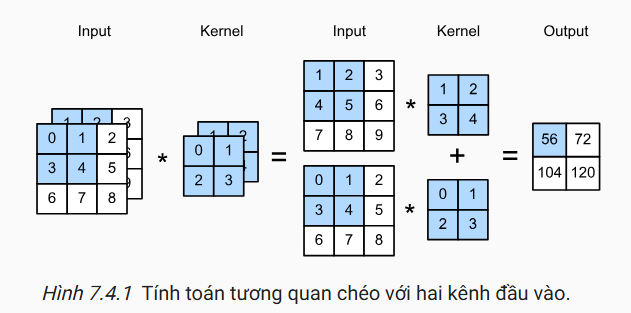

In [10]:
def corr2d_multi_in(X, K):
    # đơn giản là tính tổng của các kết quả tích chập trên tất cả các kênh đầu vào
    return sum(corr2d(x, k) for x, k in zip(X, K))

X = torch.tensor([[[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]],
                 [[1.0, 2.0, 3.0], [4.0, 5.0, 6.0], [7.0, 8.0, 9.0]]])

K = torch.tensor([[[0.0, 1.0], [2.0, 3.0]], [[1.0, 2.0], [3.0, 4.0]]])

Y = corr2d_multi_in(X, K)
print(Y)

tensor([[ 56.,  72.],
        [104., 120.]])


# Tích chập với nhiều kênh đầu ra

In [11]:
def corr2d_multi_in_out(X, K):
    # do K có nhiều kênh đầu ra hơn, chúng ta cần lặp qua tất cả các kênh đầu ra của K và tính tích chập đa kênh cho mỗi kênh đầu ra
    return torch.stack([corr2d_multi_in(X, k) for k in K], 0)

In [12]:
K = torch.stack((K, K + 1, K + 2), 0) # thêm 2 kênh nữa bằng cách cộng thêm 1 và 2 vào K (tất cả phần tử của K cộng thêm 1 và 2)
K.shape

torch.Size([3, 2, 2, 2])

In [13]:
K

tensor([[[[0., 1.],
          [2., 3.]],

         [[1., 2.],
          [3., 4.]]],


        [[[1., 2.],
          [3., 4.]],

         [[2., 3.],
          [4., 5.]]],


        [[[2., 3.],
          [4., 5.]],

         [[3., 4.],
          [5., 6.]]]])

In [14]:
corr2d_multi_in_out(X, K)

tensor([[[ 56.,  72.],
         [104., 120.]],

        [[ 76., 100.],
         [148., 172.]],

        [[ 96., 128.],
         [192., 224.]]])

# Lớp tích chập 1x1

thu nhỏ số lượng kênh mà giữ nguyên kích thước 1 kênh

In [15]:
def corr2d_multi_in_out_1x1(X, K):
    c_i, h, w = X.shape
    c_o = K.shape[0]
    X = X.reshape((c_i, h * w))
    K = K.reshape((c_o, c_i))
    # Matrix multiplication in the fully connected layer
    Y = torch.matmul(K, X)
    return Y.reshape((c_o, h, w))

In [17]:
X = torch.normal(0, 1, (3, 3, 3))
K = torch.normal(0, 1, (2, 3, 1, 1))
Y1 = corr2d_multi_in_out_1x1(X, K)
Y2 = corr2d_multi_in_out(X, K)
print(Y1)
print(Y2)

tensor([[[ 0.6053, -3.0752, -2.1788],
         [-0.4381, -2.7115,  1.2757],
         [ 2.8087,  2.8725,  0.3535]],

        [[-0.4308, -0.1188,  0.3014],
         [-0.4640,  0.2100, -0.2155],
         [-0.0234,  0.2736, -0.4063]]])
tensor([[[ 0.6053, -3.0752, -2.1788],
         [-0.4381, -2.7115,  1.2757],
         [ 2.8087,  2.8725,  0.3535]],

        [[-0.4308, -0.1188,  0.3014],
         [-0.4640,  0.2100, -0.2155],
         [-0.0234,  0.2736, -0.4063]]])


# Pooling
- tương tự việc giảm độ phân giải ảnh bằng cách lấy 1 giá trị cho cửa sổ p x q
- nên ta vẫn có thể phát hiện pattern ảnh dù nó có dịch chuyển vài pixel
- max pooling dùng rộng rãi hơn average pooling

In [18]:
def pool2d(X, pool_size, mode='max'):
    p_h, p_w = pool_size
    Y = torch.zeros((X.shape[0] - p_h + 1, X.shape[1] - p_w + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            if mode == 'max':
                Y[i, j] = X[i: i + p_h, j: j + p_w].max()
            elif mode == 'avg':
                Y[i, j] = X[i: i + p_h, j: j + p_w].mean()
    return Y

In [19]:
X = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
pool2d(X, (2, 2))

tensor([[4., 5.],
        [7., 8.]])

In [20]:
pool2d(X, (2, 2), 'avg')

tensor([[2., 3.],
        [5., 6.]])

Pooling dùng pytorch

In [ ]:
X = torch.arange(16, dtype=torch.float32).reshape((1, 1, 4, 4)) # 1 example, 1 channel, 4 rows, 4 columns
X

tensor([[[[ 0.,  1.,  2.,  3.],
          [ 4.,  5.,  6.,  7.],
          [ 8.,  9., 10., 11.],
          [12., 13., 14., 15.]]]])

In [ ]:
pool2d = nn.MaxPool2d(3) # ko có tham số, chỉ cần khai báo kích thước của cửa sổ pooling -> kích thước của cửa sổ pooling là 3x3, stride mặc định là kích thước của cửa sổ pooling, tức là 3x3

pool2d(X)

tensor([[[[10.]]]])

In [23]:
pool2d = nn.MaxPool2d(3, padding=1, stride=2)
pool2d(X)

tensor([[[[ 5.,  7.],
          [13., 15.]]]])

In [24]:
# pooling cho cửa số chữ nhật
pool2d = nn.MaxPool2d((2, 3), stride=(2, 3), padding=(0, 1))
pool2d(X)

tensor([[[[ 5.,  7.],
          [13., 15.]]]])

In [25]:
#pooling nhiều kênh
X = torch.cat((X, X + 1), 1)
X

tensor([[[[ 0.,  1.,  2.,  3.],
          [ 4.,  5.,  6.,  7.],
          [ 8.,  9., 10., 11.],
          [12., 13., 14., 15.]],

         [[ 1.,  2.,  3.,  4.],
          [ 5.,  6.,  7.,  8.],
          [ 9., 10., 11., 12.],
          [13., 14., 15., 16.]]]])

In [27]:
pool2d = nn.MaxPool2d(3, padding=1, stride=2)
pool2d(X)

tensor([[[[ 5.,  7.],
          [13., 15.]],

         [[ 6.,  8.],
          [14., 16.]]]])